In [58]:
import pandas as pd
import numpy as np
import random
from collections import Counter

In [59]:
elo_df = pd.read_csv("../data/team_elo_ratings.csv")

In [60]:
elo_dict = dict(zip(elo_df["team"],elo_df["elo"]))

elo_dict["Argentina"]

1929.841599274389

CALCULATING PROB

In [61]:
def win_probability(team_a, team_b):

    ra = elo_dict[team_a]
    rb = elo_dict[team_b]

    return 1 / (
        1 + 10 ** ((rb - ra) / 400)
    )

In [62]:
win_probability("Argentina","France")

0.5840753779513737

SIM KNOCKOUT MATCH

In [63]:
def simulate_match(team_a,team_b):
    p = win_probability(team_a,team_b)

    if random.random() < p:
        return team_a
    else:
        return team_b

In [64]:
for i in range(10):
    print(simulate_match("Argentina","France"))

France
Argentina
France
France
Argentina
France
Argentina
Argentina
Argentina
France


MINI TOURNAMENT 

In [65]:
teams = ["Argentina","Spain","France","Brazil","England","Portugal","Germany","Netherlands"]
#using random choices

random.shuffle(teams)

In [66]:
def simulate_tournament():
    qf1 = simulate_match("Argentina","Netherlands")

    qf2 = simulate_match("Spain","Germany")

    qf3 = simulate_match("France","Portugal")

    qf4 = simulate_match("Brazil","England")

    sf1 = simulate_match(qf1,qf2)

    sf2 = simulate_match(qf3,qf4)

    champion = simulate_match(sf1,sf2)

    return champion

In [67]:
simulate_tournament()

'Germany'

MONTE CARLO SIM (try out)

In [68]:
results = []

In [69]:
for i in range(10000):

    results.append(
        simulate_tournament()
)

In [70]:
champions = Counter(results)

In [71]:
for team, wins in champions.items():
    print(team,round(wins / 10000 * 100,2),"%")

Portugal 9.47 %
Brazil 11.27 %
France 13.7 %
Argentina 23.75 %
Germany 7.45 %
Spain 20.14 %
England 8.71 %
Netherlands 5.51 %


VISUAL INFO

In [72]:
import matplotlib.pyplot as plt

In [73]:
teams = list(
    champions.keys()
)

probs = [
    wins / 10000 * 100
    for wins in champions.values()
]

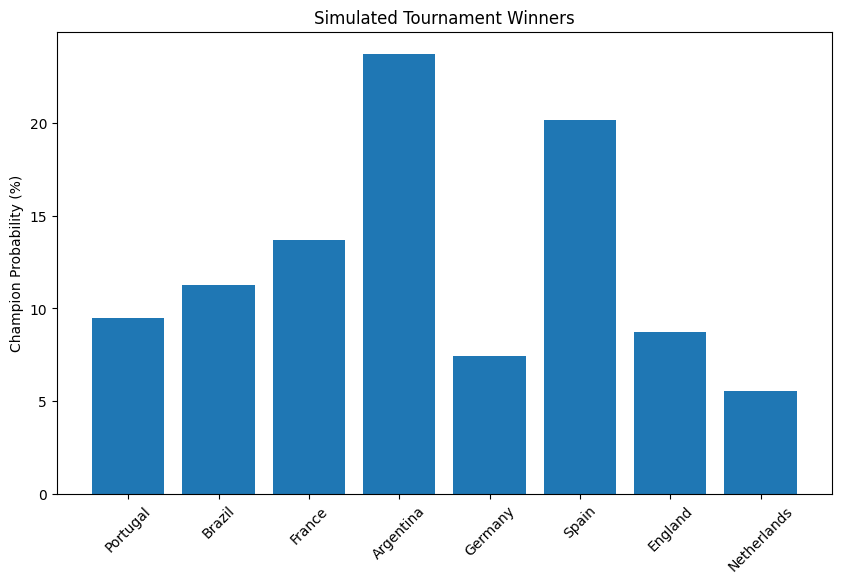

In [74]:
plt.figure(figsize=(10,6))

plt.bar(teams,probs)

plt.xticks(rotation=45)

plt.ylabel("Champion Probability (%)")

plt.title("Simulated Tournament Winners")

plt.show()